In [1]:
import requests
import numpy as np
import hdbscan
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
import umap
import random
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner
import pandas as pd
from sklearn.metrics import f1_score, fbeta_score
import joblib

In [3]:
cities = {
    "Москва": (55.75, 37.62),
    "Санкт-Петербург": (59.93, 30.32),
    "Новосибирск": (54.99, 82.90),
    "Екатеринбург": (56.83, 60.60),
    "Казань": (55.78, 49.12),
    "Челябинск": (55.15, 61.43),
    "Омск": (54.99, 73.37),
    "Самара": (53.20, 50.15),
    "Ростов-на-Дону": (47.23, 39.72),
    "Уфа": (54.73, 55.94),
    "Красноярск": (56.01, 92.87),
    "Пермь": (58.01, 56.23),
    "Воронеж": (51.67, 39.18),
    "Волгоград": (48.71, 44.51),
    "Краснодар": (45.04, 38.98),
    "Иркутск": (52.29, 104.28),
    "Хабаровск": (48.48, 135.08),
    "Владивосток": (43.11, 131.88),
    "Тюмень": (57.15, 68.99),
    "Барнаул": (53.35, 83.75),
}

weather_descriptions = {
    0: "ясно", 1: "преимущественно ясно", 2: "переменная облачность",
    3: "пасмурно", 45: "туман", 48: "изморозь", 51: "лёгкая морось",
    53: "умеренная морось", 61: "небольшой дождь", 63: "умеренный дождь",
    65: "сильный дождь", 71: "небольшой снег", 73: "умеренный снег",
    75: "сильный снег", 80: "ливень", 95: "гроза",
}


def clean_text(text):
    return text.replace('\xa0', ' ').strip()


def fetch_weather_texts(cities):
    texts = []
    for city, (lat, lon) in cities.items():
        url = "https://api.open-meteo.com/v1/forecast"
        params = {
            "latitude": lat, "longitude": lon,
            "hourly": "temperature_2m,windspeed_10m,weathercode",
            "forecast_days": 16,
            "past_days": 30
        }
        r = requests.get(url, params=params)
        data = r.json()
        hourly = data["hourly"]

        for i in range(0, len(hourly["time"]), 3):
            code = hourly["weathercode"][i]
            desc = weather_descriptions.get(code, "облачно")
            temp = hourly["temperature_2m"][i]
            wind = hourly["windspeed_10m"][i]
            if temp is None or wind is None or code is None:
                continue
            text = f"В городе {city}: {desc}, температура {temp:.0f}°C, ветер {wind:.0f} км/ч."
            texts.append(text)

    return texts



In [4]:
import pandas as pd

df = pd.read_csv("lenta-ru-news.csv")
# Аномальные — происшествия, катастрофы, политика
anomaly_df = df[df["title"].str.contains("происшествия|катастроф|чрезвычайн|война|конфликт|авария",
                                          case=False, na=False)]
anomaly_test_texts = anomaly_df["title"].dropna().sample(frac=1, random_state=42).tolist()[:50]
anomaly_val_texts = anomaly_df["title"].dropna().sample(frac=1, random_state=42).tolist()[50:200]

anomaly_test_texts = [clean_text(t) for t in anomaly_test_texts]
anomaly_val_texts = [clean_text(t) for t in anomaly_val_texts]
print(f"Тестовых Аномалий: {len(anomaly_test_texts)}")





C:\Users\Админ\AppData\Local\Temp\ipykernel_26380\1936340579.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("lenta-ru-news.csv")


Тестовых Аномалий: 50


In [5]:
all_weather_texts = fetch_weather_texts(cities)
all_weather_texts = [clean_text(t) for t in all_weather_texts]


random.seed(42)
random.shuffle(all_weather_texts)

print(f"Всего погодных: {len(all_weather_texts)}")

# 40% train, 40% val, 20% test
split = int(len(all_weather_texts) * 0.4)
val_split = int(len(all_weather_texts) * 0.8)

train_weather_texts = all_weather_texts[:split]
val_weather_texts = all_weather_texts[split:val_split]
test_weather_texts = all_weather_texts[val_split:]


print(f"Train: {len(train_weather_texts)}, Val: {len(val_weather_texts)}, Test: {len(test_weather_texts)}")

# Финальный датасет
train_texts = train_weather_texts
val_texts = val_weather_texts + anomaly_val_texts
test_texts = test_weather_texts + anomaly_test_texts

test_labels = [0]*len(test_weather_texts) + [1]*len(anomaly_test_texts)
val_labels = [0]*len(val_weather_texts) + [1]*len(anomaly_val_texts)

Всего погодных: 7360
Train: 2944, Val: 2944, Test: 1472


In [40]:
print(anomaly_test_texts)
print(val_weather_texts)

['Британские нефтяники попросили  регулятора вмешаться в конфликт с Минприроды РФ', 'Обвиняемый в гибели «Локомотива» назвал причину катастрофы', 'Учения в кенийском аэропорту приняли за авиакатастрофу', 'Активиста арт-группы "Война" забрали в военкомат', '«Бавария» заплатила рекордные деньги за еще одного чемпиона мира', 'Звезда фильма «Живот» погиб в автокатастрофе', 'Число погибших при катастрофе поезда в Японии возрасло', 'Путин оказался главным героем российских СМИ во время "газового конфликта"', 'Из-за катастрофы "Стрижи" не полетели на авиашоу в Тюмени', 'Депутат Думы предложил запретить Хеллоуин из-за авиакатастрофы', 'Война с Россией напугала Порошенко сильнее Чернобыля', 'Найдена самая близкая к Земле двойная черная дыра', 'Саакашвили открыл детский лагерь в зоне вооруженного конфликта', 'Российским чиновникам пригрозили пивной катастрофой', 'В Швейцарии по вине черепахи произошла автокатастрофа', 'Чрезвычайное положение в Южной Осетии: отправлены в отставку главы ключевых в

In [2]:
import sys
print(sys.executable)

c:\System\envs\dl\python.exe


Векторизация

In [6]:
from sentence_transformers import SentenceTransformer

MODEL_NAME =  "paraphrase-multilingual-MiniLM-L12-v2"
print(f"\nЗагрузка модели: {MODEL_NAME}")
model = SentenceTransformer(MODEL_NAME)



Загрузка модели: paraphrase-multilingual-MiniLM-L12-v2


In [7]:
from sentence_transformers import SentenceTransformer
model2 = SentenceTransformer("all-MiniLM-L6-v2")

In [8]:
from sentence_transformers import SentenceTransformer
model3 = SentenceTransformer("cointegrated/rubert-tiny2")

In [9]:
from sentence_transformers import SentenceTransformer
# Лучшая многоязычная модель для русского — в 3 раза мощнее tiny2
model4 = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

In [10]:
embedding_models = [model2,model3,model4]

train_embeddings_list=[]
val_embeddings_list = []
test_embeddings_list = []

for emb_model in embedding_models:
    train_embeddings = emb_model.encode(train_weather_texts, show_progress_bar = True, batch_size = 32)
    val_embeddings = emb_model.encode(val_texts, show_progress_bar = True, batch_size = 32)
    test_embeddings = emb_model.encode(test_texts, show_progress_bar = True, batch_size = 32)

    train_embeddings = normalize(train_embeddings, norm='l2')
    val_embeddings = normalize(val_embeddings, norm='l2')
    test_embeddings = normalize(test_embeddings, norm='l2')


    train_embeddings_list.append(train_embeddings)
    val_embeddings_list.append(val_embeddings)
    test_embeddings_list.append(test_embeddings)

TRAIN_EMBEDDINGS_RAW = np.concatenate(train_embeddings_list, axis=1)
VAL_EMBEDDINGS_RAW = np.concatenate(val_embeddings_list, axis=1)
TEST_EMBEDDINGS_RAW = np.concatenate(test_embeddings_list, axis=1)

print(f"Форма тензора Трейн эмбеддингов: {TRAIN_EMBEDDINGS_RAW.shape}")   # 
print(f"Форма тензора Валидационных эмбеддингов: {VAL_EMBEDDINGS_RAW.shape}")
print(f"Форма тензора Тестовых эмбеддингов: {TEST_EMBEDDINGS_RAW.shape}")

Batches:   0%|          | 0/92 [00:00<?, ?it/s]

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Batches:   0%|          | 0/92 [00:00<?, ?it/s]

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Batches:   0%|          | 0/92 [00:00<?, ?it/s]

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Форма тензора Трейн эмбеддингов: (2944, 1464)
Форма тензора Валидационных эмбеддингов: (3094, 1464)
Форма тензора Тестовых эмбеддингов: (1522, 1464)


OPTUNA

In [14]:
parameters_grid = {
    "min_cluster_size":              (20, 300),
    "min_samples":                   (1, 20),
    "cluster_selection_epsilon":     (0.0, 1.0),
    "cluster_selection_persistence": (0.0, 1.0),
    "metric":                        ["euclidean", "manhattan"],
    "alpha":                         (0.5, 1.5),
    "cluster_selection_method":      ["eom", "leaf"],
    "allow_single_cluster":          [True, False],
    "n_components":                  (6,15),
    "n_neighbors":                  (5,30),
    "min_dist":                      (0.0, 0.2)
}

TPE_SAMPLER = TPESampler(
    n_startup_trials=10,        # первые 10 trials — случайные (для исследования)
    n_ei_candidates=24,          # кандидаты для Expected Improvement (дефолт)
    multivariate=True,           # учитывать корреляции между параметрами
    group=True,                  # группировать связанные параметры
    seed=42,                     # воспроизводимость
    constant_liar=False,         # для параллельных запусков, у вас не нужно
)

HYPBAND_PRUNER = HyperbandPruner(
    min_resource=1,              # минимум ресурсов на trial (у вас = 1 fold)
    max_resource=3,              # максимум = n_folds = 3
    reduction_factor=3,          # агрессивность отсева плохих trials
)



n_fold = 3

In [15]:
def objective(trial):
    
    parameters = {
        "min_cluster_size":              trial.suggest_int("min_cluster_size", *parameters_grid["min_cluster_size"]),
        "min_samples":                   trial.suggest_int("min_samples", *parameters_grid["min_samples"]),
        "cluster_selection_epsilon":     trial.suggest_float("cluster_selection_epsilon", *parameters_grid["cluster_selection_epsilon"]),
        "cluster_selection_persistence": trial.suggest_float("cluster_selection_persistence", *parameters_grid["cluster_selection_persistence"]),
        "metric":                        trial.suggest_categorical("metric", parameters_grid["metric"]),
        "alpha":                         trial.suggest_float("alpha", *parameters_grid["alpha"]),
        "cluster_selection_method":      trial.suggest_categorical("cluster_selection_method", parameters_grid["cluster_selection_method"]),
        "allow_single_cluster":          trial.suggest_categorical("allow_single_cluster", parameters_grid["allow_single_cluster"]),
    }

    umap_parameters = {"n_components":   trial.suggest_int("n_components", *parameters_grid["n_components"]),
                       "n_neighbors":   trial.suggest_int("n_neighbors", *parameters_grid["n_neighbors"]),
                       "min_dist":   trial.suggest_float("min_dist", *parameters_grid["min_dist"])}

    reducer = umap.UMAP(**umap_parameters,
                    metric = "cosine",
                    random_state=42)
    
    TRAIN_EMBEDDINGS = reducer.fit_transform(TRAIN_EMBEDDINGS_RAW)
    VAL_EMBEDDINGS = reducer.transform(VAL_EMBEDDINGS_RAW)


    X_train = TRAIN_EMBEDDINGS
    X_val = VAL_EMBEDDINGS
    y_val = np.array(val_labels)

    fold_1 = X_train[:(len(X_train)//n_fold)]
    fold_2 = X_train[len(X_train)//n_fold:(len(X_train) - (len(X_train)//n_fold))] # здесь fold_ - тренировочные погодные данные
    fold_3 = X_train[(len(X_train) - (len(X_train)//n_fold)):]
    
    val_1 = X_val[:(len(X_val)//n_fold)]
    val_2 = X_val[len(X_val)//n_fold:(len(X_val) - (len(X_val)//n_fold))]  # валидационные размеченные данные(погодные + аномалии)
    val_3 = X_val[(len(X_val) - (len(X_val)//n_fold)):]

    y_val_1 = y_val[:(len(y_val)//n_fold)]
    y_val_2 = y_val[len(y_val)//n_fold:(len(y_val) - (len(y_val)//n_fold))]
    y_val_3 = y_val[(len(y_val) - (len(y_val)//n_fold)):]

    folds = [fold_1, fold_2, fold_3]
    vals = [val_1,val_2,val_3]
    y_vals = [y_val_1, y_val_2, y_val_3]


    f1_scores = []


    fold_num=0
    for fold in folds:
        
        train_folds = [folds[i] for i in range(len(folds)) if i != fold_num]
        x_train = np.concatenate(train_folds, axis=0)
        
        x_val = np.concatenate([fold,vals[fold_num]], axis=0)
        y_vali = np.concatenate([np.zeros(len(fold), dtype=int),y_vals[fold_num]])
        
        try:
            clusterer = hdbscan.HDBSCAN(**parameters, prediction_data = True).fit(x_train)
            _, strengths = hdbscan.approximate_predict(clusterer, x_val)
        except (IndexError, ValueError, RuntimeError) as e:
            return 0.0
        mask_in_cluster = clusterer.labels_ != -1
        if mask_in_cluster.sum() < 2:
            return 0.0

        best_f1 = 0.0
        for threshold in np.arange(0.05, 0.5, 0.05):
            predictions = (strengths < threshold).astype(int)
            f1 = f1_score(y_vali, predictions, zero_division=0)
            best_f1 = max(best_f1, f1)
        f1_scores.append(best_f1)
        
        intermediate = np.mean(f1_scores)
        trial.report(intermediate, fold_num)#Pruning
        if trial.should_prune():
            raise optuna.TrialPruned()
        
        fold_num+=1

    return np.mean(f1_scores)

In [16]:
STUDY = optuna.create_study(
    direction="maximize",
    sampler = TPE_SAMPLER,
    pruner = HYPBAND_PRUNER,
)
N_TRIALS = 100


print("Оптимизация началась.")
STUDY.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True, n_jobs = 2)


print("Количество завершенных испытаний: ", len(STUDY.trials))
print("Лучшее испытание:")
TRIAL = STUDY.best_trial



print("  Значение метрики (F1): ", TRIAL.value)
print("  Лучшие гиперпараметры: ")
for key, value in TRIAL.params.items():
    print(f"    {key}: {value}")

[I 2026-05-13 16:06:33,621] A new study created in memory with name: no-name-adaaa305-e98c-486c-b664-e094fdeb1a2e


Оптимизация началась.


  0%|          | 0/100 [00:00<?, ?it/s]

c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\System\envs\dl\Lib\site-packages\hdbscan\prediction.py:391: UserWarning: Clusterer does not have any defined clusters, new data will be automatically predicted as noise.
  warn('Clusterer does not have any defined clusters, new data'
c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:09:14,379] Trial 1 finished with value: 0.0 and parameters: {'min_cluster_size': 125, 'min_samples': 5, 'cluster_selection_epsilon': 0.5908828214037901, 'cluster_selection_persistence': 0.9989230293250282, 'metric': 'manhattan', 'alpha': 0.5530735720977047, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 7, 'n_neighbors': 22, 'min_dist': 0.18383006720879655}. Best is trial 1 with value: 0.0.
[I 2026-05-13 16:09:19,143] Trial 0 finished with value: 0.0984848484848485 and parameters: {'min_cluster_size': 65, 'min_samples': 13, 'cluster_selection_epsilon': 0.35349533908774766, 'cluster_selection_persistence': 0.8189672336319057, 'metric': 'euclidean', 'alpha': 1.225185858543402, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 10, 'n_neighbors': 16, 'min_dist': 0.19734160597470254}. Best is trial 0 with value: 0.0984848484848485.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:11:33,729] Trial 3 finished with value: 0.058457711442786074 and parameters: {'min_cluster_size': 130, 'min_samples': 4, 'cluster_selection_epsilon': 0.8233650265946946, 'cluster_selection_persistence': 0.32915162349500926, 'metric': 'manhattan', 'alpha': 1.017570279251027, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 8, 'n_neighbors': 29, 'min_dist': 0.08639370167454122}. Best is trial 0 with value: 0.0984848484848485.
[I 2026-05-13 16:11:33,729] Trial 2 finished with value: 0.13505747126436782 and parameters: {'min_cluster_size': 30, 'min_samples': 6, 'cluster_selection_epsilon': 0.6061406444713249, 'cluster_selection_persistence': 0.5412342215199781, 'metric': 'manhattan', 'alpha': 0.9733312441816191, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 14, 'n_neighbors': 28, 'min_dist': 0.030824561479379665}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:13:58,042] Trial 4 finished with value: 0.055865921787709494 and parameters: {'min_cluster_size': 199, 'min_samples': 7, 'cluster_selection_epsilon': 0.697945747934692, 'cluster_selection_persistence': 0.09607534250133865, 'metric': 'euclidean', 'alpha': 0.8531505273977729, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 22, 'min_dist': 0.09941182981222361}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:14:01,731] Trial 5 finished with value: 0.044685990338164255 and parameters: {'min_cluster_size': 130, 'min_samples': 10, 'cluster_selection_epsilon': 0.19149083980184112, 'cluster_selection_persistence': 0.2381391801426317, 'metric': 'euclidean', 'alpha': 0.6658841902004115, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 7, 'n_neighbors': 25, 'min_dist': 0.03010843559819816}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\System\envs\dl\Lib\site-packages\hdbscan\prediction.py:391: UserWarning: Clusterer does not have any defined clusters, new data will be automatically predicted as noise.
  warn('Clusterer does not have any defined clusters, new data'
c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:16:20,904] Trial 6 finished with value: 0.0 and parameters: {'min_cluster_size': 218, 'min_samples': 10, 'cluster_selection_epsilon': 0.3243954333649385, 'cluster_selection_persistence': 0.18161566649177152, 'metric': 'manhattan', 'alpha': 1.2067018400926326, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 13, 'n_neighbors': 8, 'min_dist': 0.19390196517049813}. Best is trial 2 with value: 0.13505747126436782.
[I 2026-05-13 16:16:31,116] Trial 7 finished with value: 0.10909090909090909 and parameters: {'min_cluster_size': 74, 'min_samples': 12, 'cluster_selection_epsilon': 0.9204498471997947, 'cluster_selection_persistence': 0.5419356198483589, 'metric': 'manhattan', 'alpha': 0.5099348156589628, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 8, 'n_neighbors': 16, 'min_dist': 0.04662643168622254}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\System\envs\dl\Lib\site-packages\hdbscan\prediction.py:391: UserWarning: Clusterer does not have any defined clusters, new data will be automatically predicted as noise.
  warn('Clusterer does not have any defined clusters, new data'
c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:18:48,347] Trial 9 finished with value: 0.0 and parameters: {'min_cluster_size': 220, 'min_samples': 1, 'cluster_selection_epsilon': 0.8957638292411043, 'cluster_selection_persistence': 0.16670574861514897, 'metric': 'manhattan', 'alpha': 0.9065334512053125, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 11, 'n_neighbors': 21, 'min_dist': 0.08309206972664498}. Best is trial 2 with value: 0.13505747126436782.
[I 2026-05-13 16:18:48,561] Trial 8 finished with value: 0.08108108108108109 and parameters: {'min_cluster_size': 23, 'min_samples': 12, 'cluster_selection_epsilon': 0.7192960656768338, 'cluster_selection_persistence': 0.855441693581012, 'metric': 'euclidean', 'alpha': 1.3205353627256766, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 9, 'n_neighbors': 7, 'min_dist': 0.15549467206290737}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\System\envs\dl\Lib\site-packages\hdbscan\prediction.py:391: UserWarning: Clusterer does not have any defined clusters, new data will be automatically predicted as noise.
  warn('Clusterer does not have any defined clusters, new data'
c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:21:12,586] Trial 10 finished with value: 0.0 and parameters: {'min_cluster_size': 296, 'min_samples': 1, 'cluster_selection_epsilon': 0.5310047556501398, 'cluster_selection_persistence': 0.5467481784400237, 'metric': 'manhattan', 'alpha': 0.7041525103780503, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 11, 'n_neighbors': 8, 'min_dist': 0.0939907111827537}. Best is trial 2 with value: 0.13505747126436782.
[I 2026-05-13 16:21:20,306] Trial 11 finished with value: 0.05516431924882629 and parameters: {'min_cluster_size': 94, 'min_samples': 8, 'cluster_selection_epsilon': 0.3834811176528329, 'cluster_selection_persistence': 0.5639474905615507, 'metric': 'manhattan', 'alpha': 0.8654622209706636, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 14, 'n_neighbors': 18, 'min_dist': 0.014389956168227924}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\System\envs\dl\Lib\site-packages\hdbscan\prediction.py:391: UserWarning: Clusterer does not have any defined clusters, new data will be automatically predicted as noise.
  warn('Clusterer does not have any defined clusters, new data'
c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:23:39,605] Trial 13 finished with value: 0.0 and parameters: {'min_cluster_size': 127, 'min_samples': 16, 'cluster_selection_epsilon': 0.9861416813781586, 'cluster_selection_persistence': 0.5740386792432027, 'metric': 'manhattan', 'alpha': 0.613783318509348, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 6, 'n_neighbors': 19, 'min_dist': 0.010783466218375594}. Best is trial 2 with value: 0.13505747126436782.
[I 2026-05-13 16:23:40,728] Trial 12 finished with value: 0.1235632183908046 and parameters: {'min_cluster_size': 52, 'min_samples': 9, 'cluster_selection_epsilon': 0.5378133809628818, 'cluster_selection_persistence': 0.5914430574677793, 'metric': 'manhattan', 'alpha': 1.009411112119595, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 12, 'n_neighbors': 24, 'min_dist': 0.06263579079034198}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:26:03,444] Trial 14 finished with value: 0.05385450597176982 and parameters: {'min_cluster_size': 98, 'min_samples': 8, 'cluster_selection_epsilon': 0.9345095533543668, 'cluster_selection_persistence': 0.4855112217701676, 'metric': 'manhattan', 'alpha': 0.5991381773565969, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 9, 'n_neighbors': 9, 'min_dist': 0.11716047091615076}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:26:10,316] Trial 15 finished with value: 0.08262108262108263 and parameters: {'min_cluster_size': 30, 'min_samples': 5, 'cluster_selection_epsilon': 0.7967456911743831, 'cluster_selection_persistence': 0.6796781768778594, 'metric': 'euclidean', 'alpha': 0.7420274242921343, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 13, 'n_neighbors': 29, 'min_dist': 0.06815850165048366}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:28:31,881] Trial 16 finished with value: 0.10594315245478036 and parameters: {'min_cluster_size': 74, 'min_samples': 3, 'cluster_selection_epsilon': 0.8188877858628106, 'cluster_selection_persistence': 0.37109936152576584, 'metric': 'euclidean', 'alpha': 1.2209756694833211, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 12, 'n_neighbors': 22, 'min_dist': 0.022924809024459897}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:28:36,386] Trial 17 finished with value: 0.11838006230529595 and parameters: {'min_cluster_size': 41, 'min_samples': 11, 'cluster_selection_epsilon': 0.7348160775527811, 'cluster_selection_persistence': 0.5201575905496609, 'metric': 'manhattan', 'alpha': 1.0466215764501663, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 10, 'n_neighbors': 30, 'min_dist': 0.033323308514316315}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:31:01,601] Trial 18 finished with value: 0.125 and parameters: {'min_cluster_size': 54, 'min_samples': 2, 'cluster_selection_epsilon': 0.36944871827018055, 'cluster_selection_persistence': 0.030779595819121597, 'metric': 'manhattan', 'alpha': 0.9229713038557458, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 27, 'min_dist': 0.05291612229678733}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:31:06,835] Trial 19 finished with value: 0.11725293132328309 and parameters: {'min_cluster_size': 61, 'min_samples': 10, 'cluster_selection_epsilon': 0.4399846206868409, 'cluster_selection_persistence': 0.3987667226995707, 'metric': 'manhattan', 'alpha': 1.00255904249164, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 26, 'min_dist': 0.15210347538490698}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:33:31,506] Trial 20 finished with value: 0.1292517006802721 and parameters: {'min_cluster_size': 53, 'min_samples': 1, 'cluster_selection_epsilon': 0.58303897537291, 'cluster_selection_persistence': 0.18713038127719345, 'metric': 'manhattan', 'alpha': 0.9197296569989657, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 30, 'min_dist': 0.004849722979329972}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:33:36,447] Trial 21 finished with value: 0.11956521739130434 and parameters: {'min_cluster_size': 75, 'min_samples': 1, 'cluster_selection_epsilon': 0.42266015223093234, 'cluster_selection_persistence': 0.11796362827672104, 'metric': 'manhattan', 'alpha': 1.2356266245498357, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 13, 'n_neighbors': 28, 'min_dist': 0.0393765531918633}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:35:59,986] Trial 22 finished with value: 0.04663923182441701 and parameters: {'min_cluster_size': 100, 'min_samples': 1, 'cluster_selection_epsilon': 0.5610845590191765, 'cluster_selection_persistence': 0.051321859409314635, 'metric': 'manhattan', 'alpha': 0.8405470193077074, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 29, 'min_dist': 0.017694171354095563}. Best is trial 2 with value: 0.13505747126436782.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:36:06,926] Trial 23 finished with value: 0.20242914979757085 and parameters: {'min_cluster_size': 36, 'min_samples': 3, 'cluster_selection_epsilon': 0.6216174388870791, 'cluster_selection_persistence': 0.16010737244792606, 'metric': 'manhattan', 'alpha': 0.7016927870670306, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 30, 'min_dist': 0.02501643385313636}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:38:22,256] Trial 24 finished with value: 0.13983739837398373 and parameters: {'min_cluster_size': 45, 'min_samples': 2, 'cluster_selection_epsilon': 0.2891909570140377, 'cluster_selection_persistence': 0.3200604843427215, 'metric': 'euclidean', 'alpha': 0.8360935002204936, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 13, 'n_neighbors': 24, 'min_dist': 0.000969058975943089}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:38:26,826] Trial 25 finished with value: 0.08635578583765112 and parameters: {'min_cluster_size': 35, 'min_samples': 11, 'cluster_selection_epsilon': 0.9467748429273513, 'cluster_selection_persistence': 0.07062298605787315, 'metric': 'euclidean', 'alpha': 0.805947113016592, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 14, 'n_neighbors': 30, 'min_dist': 0.07909121252847823}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:40:42,926] Trial 26 finished with value: 0.13190730837789663 and parameters: {'min_cluster_size': 66, 'min_samples': 5, 'cluster_selection_epsilon': 0.08440237288126115, 'cluster_selection_persistence': 0.10614593499893979, 'metric': 'euclidean', 'alpha': 0.7823065551910265, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 13, 'n_neighbors': 24, 'min_dist': 0.032635104997513965}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:40:45,823] Trial 27 finished with value: 0.14625850340136054 and parameters: {'min_cluster_size': 73, 'min_samples': 1, 'cluster_selection_epsilon': 0.10402962854814521, 'cluster_selection_persistence': 0.20895375297452723, 'metric': 'euclidean', 'alpha': 0.6543966947660218, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 11, 'n_neighbors': 29, 'min_dist': 0.014622262983105481}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:43:02,147] Trial 28 finished with value: 0.14942528735632185 and parameters: {'min_cluster_size': 42, 'min_samples': 1, 'cluster_selection_epsilon': 0.06598827788933953, 'cluster_selection_persistence': 0.3929253626628117, 'metric': 'euclidean', 'alpha': 0.829372919890961, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 11, 'n_neighbors': 21, 'min_dist': 0.0022043278458062886}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:43:05,665] Trial 29 finished with value: 0.15458937198067632 and parameters: {'min_cluster_size': 57, 'min_samples': 1, 'cluster_selection_epsilon': 0.09067463603340774, 'cluster_selection_persistence': 0.49926738297060075, 'metric': 'euclidean', 'alpha': 0.8728002018324523, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 10, 'n_neighbors': 30, 'min_dist': 0.042009361694931024}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:45:17,479] Trial 30 finished with value: 0.07885304659498209 and parameters: {'min_cluster_size': 84, 'min_samples': 7, 'cluster_selection_epsilon': 0.06631685064004916, 'cluster_selection_persistence': 0.21395718305471162, 'metric': 'euclidean', 'alpha': 0.6011517269871017, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 11, 'n_neighbors': 25, 'min_dist': 0.06660082332878167}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:45:18,578] Trial 31 finished with value: 0.1021825396825397 and parameters: {'min_cluster_size': 20, 'min_samples': 5, 'cluster_selection_epsilon': 0.04350316519196265, 'cluster_selection_persistence': 0.7134619150528986, 'metric': 'euclidean', 'alpha': 0.9018421873393352, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 9, 'n_neighbors': 29, 'min_dist': 0.0396367784888779}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:47:31,958] Trial 32 finished with value: 0.0564373897707231 and parameters: {'min_cluster_size': 94, 'min_samples': 1, 'cluster_selection_epsilon': 0.06223713698477783, 'cluster_selection_persistence': 0.6530956526055562, 'metric': 'euclidean', 'alpha': 0.713685492237986, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 9, 'n_neighbors': 19, 'min_dist': 0.046411730124086684}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:47:37,156] Trial 33 finished with value: 0.07619047619047618 and parameters: {'min_cluster_size': 84, 'min_samples': 4, 'cluster_selection_epsilon': 0.132483988214079, 'cluster_selection_persistence': 0.0466440845965031, 'metric': 'euclidean', 'alpha': 0.6610684350859795, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 10, 'n_neighbors': 30, 'min_dist': 0.010993044634346543}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:49:46,351] Trial 34 finished with value: 0.04487179487179487 and parameters: {'min_cluster_size': 99, 'min_samples': 2, 'cluster_selection_epsilon': 0.2522862101567649, 'cluster_selection_persistence': 0.2613907548180737, 'metric': 'euclidean', 'alpha': 0.7275435284814761, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 8, 'n_neighbors': 26, 'min_dist': 0.0019154946968001126}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:49:48,822] Trial 35 finished with value: 0.12544802867383512 and parameters: {'min_cluster_size': 57, 'min_samples': 1, 'cluster_selection_epsilon': 0.0938542818232852, 'cluster_selection_persistence': 0.4826790393677535, 'metric': 'euclidean', 'alpha': 1.1842695387221058, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 11, 'n_neighbors': 18, 'min_dist': 0.019479073363144233}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:51:59,610] Trial 36 finished with value: 0.06595365418894832 and parameters: {'min_cluster_size': 103, 'min_samples': 1, 'cluster_selection_epsilon': 0.017623931384787503, 'cluster_selection_persistence': 0.6706082586144251, 'metric': 'manhattan', 'alpha': 0.7814607573387023, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 10, 'n_neighbors': 27, 'min_dist': 0.022225670421590158}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:52:02,484] Trial 37 finished with value: 0.07981220657276995 and parameters: {'min_cluster_size': 78, 'min_samples': 1, 'cluster_selection_epsilon': 0.18819392247601813, 'cluster_selection_persistence': 0.2317916357433866, 'metric': 'euclidean', 'alpha': 0.9558209815593934, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 9, 'n_neighbors': 10, 'min_dist': 0.013561086619115039}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:54:15,143] Trial 38 finished with value: 0.09669211195928752 and parameters: {'min_cluster_size': 71, 'min_samples': 1, 'cluster_selection_epsilon': 0.030773484787419883, 'cluster_selection_persistence': 0.13876570767425417, 'metric': 'manhattan', 'alpha': 1.0164827873262172, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 11, 'n_neighbors': 26, 'min_dist': 0.0027301647212953292}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:54:20,163] Trial 39 finished with value: 0.15932914046121593 and parameters: {'min_cluster_size': 26, 'min_samples': 5, 'cluster_selection_epsilon': 0.5111998917918956, 'cluster_selection_persistence': 0.1592639595204366, 'metric': 'manhattan', 'alpha': 0.5354861476131001, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 13, 'n_neighbors': 26, 'min_dist': 0.057594565610447276}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:56:30,989] Trial 40 finished with value: 0.1679790026246719 and parameters: {'min_cluster_size': 35, 'min_samples': 5, 'cluster_selection_epsilon': 0.4311729808456121, 'cluster_selection_persistence': 0.5074469748256478, 'metric': 'manhattan', 'alpha': 0.6131715901607717, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 25, 'min_dist': 0.009819910019519746}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:56:32,271] Trial 41 finished with value: 0.1276595744680851 and parameters: {'min_cluster_size': 53, 'min_samples': 6, 'cluster_selection_epsilon': 0.620161317405809, 'cluster_selection_persistence': 0.2229312125083487, 'metric': 'manhattan', 'alpha': 0.5716801265830795, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 14, 'n_neighbors': 17, 'min_dist': 0.078281745687279}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:58:46,924] Trial 42 finished with value: 0.10113960113960113 and parameters: {'min_cluster_size': 23, 'min_samples': 7, 'cluster_selection_epsilon': 0.44829653059013036, 'cluster_selection_persistence': 0.1258188179019734, 'metric': 'manhattan', 'alpha': 0.6575048637926302, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 11, 'n_neighbors': 23, 'min_dist': 0.09019268078847244}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 16:58:48,012] Trial 43 finished with value: 0.1542111506524318 and parameters: {'min_cluster_size': 29, 'min_samples': 5, 'cluster_selection_epsilon': 0.48077636510642374, 'cluster_selection_persistence': 0.44708981914090223, 'metric': 'manhattan', 'alpha': 0.6212517954098193, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 13, 'n_neighbors': 30, 'min_dist': 0.07211785707691613}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:01:03,163] Trial 44 finished with value: 0.10600706713780918 and parameters: {'min_cluster_size': 62, 'min_samples': 6, 'cluster_selection_epsilon': 0.3205749822067248, 'cluster_selection_persistence': 0.3396860097407066, 'metric': 'manhattan', 'alpha': 0.5880240376857431, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 14, 'n_neighbors': 27, 'min_dist': 0.019096936960107995}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:01:06,613] Trial 45 finished with value: 0.11485642946317104 and parameters: {'min_cluster_size': 51, 'min_samples': 4, 'cluster_selection_epsilon': 0.1257066281036328, 'cluster_selection_persistence': 0.509962466251795, 'metric': 'manhattan', 'alpha': 0.6913151010350137, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 22, 'min_dist': 0.02875654871509538}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:03:18,835] Trial 46 finished with value: 0.11594202898550725 and parameters: {'min_cluster_size': 68, 'min_samples': 10, 'cluster_selection_epsilon': 0.6766572887032338, 'cluster_selection_persistence': 0.567560171848153, 'metric': 'manhattan', 'alpha': 0.7749622251606856, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 13, 'n_neighbors': 23, 'min_dist': 0.06072416834592393}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:03:22,611] Trial 47 finished with value: 0.10500610500610501 and parameters: {'min_cluster_size': 34, 'min_samples': 6, 'cluster_selection_epsilon': 0.4278966008027921, 'cluster_selection_persistence': 0.3675886270832524, 'metric': 'manhattan', 'alpha': 0.6928030026523402, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 11, 'n_neighbors': 26, 'min_dist': 0.14907390136594}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:05:34,295] Trial 48 finished with value: 0.09943502824858758 and parameters: {'min_cluster_size': 29, 'min_samples': 9, 'cluster_selection_epsilon': 0.4661526141886246, 'cluster_selection_persistence': 0.6280947760916926, 'metric': 'manhattan', 'alpha': 0.5078195950305926, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 12, 'n_neighbors': 24, 'min_dist': 0.08165549926450703}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:05:39,066] Trial 49 finished with value: 0.12077294685990338 and parameters: {'min_cluster_size': 44, 'min_samples': 2, 'cluster_selection_epsilon': 0.6803285733800895, 'cluster_selection_persistence': 0.6185700098103117, 'metric': 'manhattan', 'alpha': 0.641632433752747, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 11, 'n_neighbors': 29, 'min_dist': 0.01890772104662254}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:07:50,393] Trial 50 finished with value: 0.05454064072014827 and parameters: {'min_cluster_size': 108, 'min_samples': 4, 'cluster_selection_epsilon': 0.7027309549717262, 'cluster_selection_persistence': 0.4200779828117246, 'metric': 'manhattan', 'alpha': 0.7678084900668692, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 29, 'min_dist': 0.09081877099618302}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:07:54,177] Trial 51 finished with value: 0.11068211068211069 and parameters: {'min_cluster_size': 41, 'min_samples': 3, 'cluster_selection_epsilon': 0.2681887622388996, 'cluster_selection_persistence': 0.4198443687739817, 'metric': 'euclidean', 'alpha': 1.1892683618947022, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 10, 'n_neighbors': 26, 'min_dist': 0.0929675713767147}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:10:06,282] Trial 52 finished with value: 0.0906344410876133 and parameters: {'min_cluster_size': 42, 'min_samples': 7, 'cluster_selection_epsilon': 0.467717721805616, 'cluster_selection_persistence': 0.5009196272350919, 'metric': 'euclidean', 'alpha': 0.5407906516419705, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 14, 'n_neighbors': 26, 'min_dist': 0.10215485369065871}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:10:10,012] Trial 53 finished with value: 0.17816091954022986 and parameters: {'min_cluster_size': 39, 'min_samples': 2, 'cluster_selection_epsilon': 0.11922932877759067, 'cluster_selection_persistence': 0.511105847073403, 'metric': 'euclidean', 'alpha': 0.6402423850630998, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 11, 'n_neighbors': 26, 'min_dist': 0.00998436695888109}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:12:21,785] Trial 54 finished with value: 0.10752688172043011 and parameters: {'min_cluster_size': 23, 'min_samples': 2, 'cluster_selection_epsilon': 0.37826656371882766, 'cluster_selection_persistence': 0.60017075061094, 'metric': 'euclidean', 'alpha': 0.6618856665772563, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 14, 'n_neighbors': 25, 'min_dist': 0.015455149860223488}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:12:22,868] Trial 55 finished with value: 0.07571560480147738 and parameters: {'min_cluster_size': 22, 'min_samples': 4, 'cluster_selection_epsilon': 0.5755958159057146, 'cluster_selection_persistence': 0.7117731055263077, 'metric': 'euclidean', 'alpha': 0.8779202520649774, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 14, 'n_neighbors': 18, 'min_dist': 0.026966734347633574}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:14:36,991] Trial 56 finished with value: 0.1019607843137255 and parameters: {'min_cluster_size': 76, 'min_samples': 2, 'cluster_selection_epsilon': 0.002386352287769483, 'cluster_selection_persistence': 0.5244112252941999, 'metric': 'euclidean', 'alpha': 0.6084766909779467, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 11, 'n_neighbors': 24, 'min_dist': 0.08568505590587513}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:14:37,321] Trial 57 finished with value: 0.14603174603174604 and parameters: {'min_cluster_size': 23, 'min_samples': 1, 'cluster_selection_epsilon': 0.02833088434100335, 'cluster_selection_persistence': 0.4346860810182016, 'metric': 'manhattan', 'alpha': 0.8013540713056616, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 9, 'n_neighbors': 30, 'min_dist': 0.020848651683137074}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:16:52,727] Trial 58 finished with value: 0.12987012987012989 and parameters: {'min_cluster_size': 22, 'min_samples': 3, 'cluster_selection_epsilon': 0.008866421486114981, 'cluster_selection_persistence': 0.4540471066974971, 'metric': 'euclidean', 'alpha': 0.5677013288392578, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 9, 'n_neighbors': 30, 'min_dist': 0.016328844902311443}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:16:53,802] Trial 59 finished with value: 0.14814814814814814 and parameters: {'min_cluster_size': 51, 'min_samples': 5, 'cluster_selection_epsilon': 0.6487720426667747, 'cluster_selection_persistence': 0.377092979202584, 'metric': 'manhattan', 'alpha': 0.6005581790748563, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 13, 'n_neighbors': 26, 'min_dist': 0.0030620349536554237}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:19:10,068] Trial 60 finished with value: 0.17010309278350513 and parameters: {'min_cluster_size': 21, 'min_samples': 3, 'cluster_selection_epsilon': 0.44853307194999814, 'cluster_selection_persistence': 0.685282268142547, 'metric': 'manhattan', 'alpha': 0.6622925061196486, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 26, 'min_dist': 0.07775760636939556}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:19:11,158] Trial 61 finished with value: 0.08767123287671232 and parameters: {'min_cluster_size': 40, 'min_samples': 4, 'cluster_selection_epsilon': 0.45615298239625557, 'cluster_selection_persistence': 0.13714493367020708, 'metric': 'euclidean', 'alpha': 0.6924794260017679, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 30, 'min_dist': 0.07046989969506857}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:21:27,492] Trial 62 finished with value: 0.15531660692951016 and parameters: {'min_cluster_size': 27, 'min_samples': 5, 'cluster_selection_epsilon': 0.49164460176970975, 'cluster_selection_persistence': 0.6779908906853531, 'metric': 'manhattan', 'alpha': 0.8090421571646963, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 29, 'min_dist': 0.08256068631838957}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:21:28,146] Trial 63 finished with value: 0.076 and parameters: {'min_cluster_size': 103, 'min_samples': 2, 'cluster_selection_epsilon': 0.4317318227164212, 'cluster_selection_persistence': 0.8125504584248473, 'metric': 'manhattan', 'alpha': 0.5654420939076512, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 26, 'min_dist': 0.10830662079409707}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:23:43,383] Trial 64 finished with value: 0.13227513227513227 and parameters: {'min_cluster_size': 22, 'min_samples': 1, 'cluster_selection_epsilon': 0.24867699802721213, 'cluster_selection_persistence': 0.5923622313894635, 'metric': 'manhattan', 'alpha': 0.8340496210216867, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 13, 'n_neighbors': 21, 'min_dist': 0.10527825469017045}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:23:46,266] Trial 65 finished with value: 0.14545454545454545 and parameters: {'min_cluster_size': 39, 'min_samples': 3, 'cluster_selection_epsilon': 0.4954943335859368, 'cluster_selection_persistence': 0.8793505691203196, 'metric': 'manhattan', 'alpha': 0.7475955098289184, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 23, 'min_dist': 0.050476823612940085}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:26:00,888] Trial 66 finished with value: 0.1185897435897436 and parameters: {'min_cluster_size': 39, 'min_samples': 6, 'cluster_selection_epsilon': 0.23476797991827691, 'cluster_selection_persistence': 0.760849463070299, 'metric': 'euclidean', 'alpha': 0.7623601127260858, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 30, 'min_dist': 0.1336632516771285}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:26:03,666] Trial 67 finished with value: 0.09749670619235835 and parameters: {'min_cluster_size': 76, 'min_samples': 5, 'cluster_selection_epsilon': 0.555926821522379, 'cluster_selection_persistence': 0.0035551134895197845, 'metric': 'manhattan', 'alpha': 0.5222402252511582, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 14, 'n_neighbors': 26, 'min_dist': 0.03388154975724418}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:28:18,298] Trial 68 finished with value: 0.11029411764705882 and parameters: {'min_cluster_size': 49, 'min_samples': 8, 'cluster_selection_epsilon': 0.4111276980923867, 'cluster_selection_persistence': 0.7234644374046488, 'metric': 'manhattan', 'alpha': 0.7229005816809022, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 30, 'min_dist': 0.03719559665146126}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:28:21,558] Trial 69 finished with value: 0.13756613756613756 and parameters: {'min_cluster_size': 55, 'min_samples': 4, 'cluster_selection_epsilon': 0.046718598154264476, 'cluster_selection_persistence': 0.8155663375593317, 'metric': 'euclidean', 'alpha': 0.9682412576114304, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 15, 'n_neighbors': 27, 'min_dist': 0.0004606310036980449}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:30:33,898] Trial 70 finished with value: 0.10416666666666667 and parameters: {'min_cluster_size': 81, 'min_samples': 2, 'cluster_selection_epsilon': 0.30706393956394085, 'cluster_selection_persistence': 0.6627667069569584, 'metric': 'manhattan', 'alpha': 0.5799176791021008, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 14, 'n_neighbors': 23, 'min_dist': 0.019673098493359825}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:30:36,078] Trial 71 finished with value: 0.07269503546099292 and parameters: {'min_cluster_size': 71, 'min_samples': 2, 'cluster_selection_epsilon': 0.5791773496127861, 'cluster_selection_persistence': 0.6048823454535104, 'metric': 'manhattan', 'alpha': 0.6833748756303772, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 14, 'n_neighbors': 19, 'min_dist': 0.016390596519874952}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:32:50,401] Trial 72 finished with value: 0.12109623964308476 and parameters: {'min_cluster_size': 22, 'min_samples': 2, 'cluster_selection_epsilon': 0.3879729311669108, 'cluster_selection_persistence': 0.7462410403143056, 'metric': 'manhattan', 'alpha': 1.1303770175683576, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 13, 'n_neighbors': 29, 'min_dist': 0.07760784061629836}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:32:52,925] Trial 73 finished with value: 0.13515981735159818 and parameters: {'min_cluster_size': 24, 'min_samples': 2, 'cluster_selection_epsilon': 0.6574093811521868, 'cluster_selection_persistence': 0.49714589512682367, 'metric': 'manhattan', 'alpha': 0.6778383377975071, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 24, 'min_dist': 0.06617559470947476}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:35:05,833] Trial 74 finished with value: 0.13902053712480253 and parameters: {'min_cluster_size': 50, 'min_samples': 6, 'cluster_selection_epsilon': 0.6387681483004691, 'cluster_selection_persistence': 0.374795944348569, 'metric': 'manhattan', 'alpha': 0.6622667662880946, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 13, 'n_neighbors': 29, 'min_dist': 0.037684939784952465}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:35:07,201] Trial 75 finished with value: 0.1368421052631579 and parameters: {'min_cluster_size': 56, 'min_samples': 3, 'cluster_selection_epsilon': 0.3341049524333622, 'cluster_selection_persistence': 0.9010566673391037, 'metric': 'euclidean', 'alpha': 0.7134156900854528, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 11, 'n_neighbors': 19, 'min_dist': 0.016078506099955925}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:37:22,093] Trial 76 finished with value: 0.05635300372142477 and parameters: {'min_cluster_size': 123, 'min_samples': 4, 'cluster_selection_epsilon': 0.3279873750372964, 'cluster_selection_persistence': 0.17942938275225065, 'metric': 'manhattan', 'alpha': 0.5023170255662572, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 12, 'n_neighbors': 29, 'min_dist': 0.10929433566712779}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:37:27,748] Trial 77 finished with value: 0.09857328145265888 and parameters: {'min_cluster_size': 70, 'min_samples': 5, 'cluster_selection_epsilon': 0.35872189290464795, 'cluster_selection_persistence': 0.2515244401698127, 'metric': 'manhattan', 'alpha': 0.5581555216113874, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 13, 'n_neighbors': 29, 'min_dist': 0.09256874126449062}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:39:38,274] Trial 78 finished with value: 0.10392902408111533 and parameters: {'min_cluster_size': 58, 'min_samples': 4, 'cluster_selection_epsilon': 0.43280443172156075, 'cluster_selection_persistence': 0.4546030673489002, 'metric': 'manhattan', 'alpha': 0.6078610512243063, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 11, 'n_neighbors': 29, 'min_dist': 0.07725826374280499}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:39:41,501] Trial 79 finished with value: 0.09857328145265888 and parameters: {'min_cluster_size': 73, 'min_samples': 16, 'cluster_selection_epsilon': 0.5537203889514751, 'cluster_selection_persistence': 0.15992095389941427, 'metric': 'euclidean', 'alpha': 0.5253257759786731, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 13, 'n_neighbors': 26, 'min_dist': 0.05152179289464875}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:41:53,666] Trial 80 finished with value: 0.0984848484848485 and parameters: {'min_cluster_size': 155, 'min_samples': 4, 'cluster_selection_epsilon': 0.18483861717999617, 'cluster_selection_persistence': 0.41577835281541525, 'metric': 'euclidean', 'alpha': 1.1465692789708384, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 9, 'n_neighbors': 28, 'min_dist': 0.05763601621493079}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:41:59,651] Trial 81 finished with value: 0.12479474548440066 and parameters: {'min_cluster_size': 43, 'min_samples': 5, 'cluster_selection_epsilon': 0.16586467436370092, 'cluster_selection_persistence': 0.43734466451083365, 'metric': 'euclidean', 'alpha': 0.895765856957983, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 12, 'n_neighbors': 28, 'min_dist': 0.13635097411111352}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\System\envs\dl\Lib\site-packages\hdbscan\prediction.py:391: UserWarning: Clusterer does not have any defined clusters, new data will be automatically predicted as noise.
  warn('Clusterer does not have any defined clusters, new data'


[I 2026-05-13 17:44:06,081] Trial 82 finished with value: 0.0 and parameters: {'min_cluster_size': 118, 'min_samples': 1, 'cluster_selection_epsilon': 0.21737236657180142, 'cluster_selection_persistence': 0.5976094628570652, 'metric': 'euclidean', 'alpha': 0.8887553416735064, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 11, 'n_neighbors': 24, 'min_dist': 0.02411154127169199}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:44:16,026] Trial 83 finished with value: 0.11935953420669577 and parameters: {'min_cluster_size': 32, 'min_samples': 5, 'cluster_selection_epsilon': 0.16975635886712565, 'cluster_selection_persistence': 0.4509368332105482, 'metric': 'euclidean', 'alpha': 0.7524588984914249, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 10, 'n_neighbors': 11, 'min_dist': 0.028629806049995734}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:46:22,675] Trial 84 finished with value: 0.16091954022988506 and parameters: {'min_cluster_size': 36, 'min_samples': 2, 'cluster_selection_epsilon': 0.07338084328451944, 'cluster_selection_persistence': 0.399156315717946, 'metric': 'euclidean', 'alpha': 1.0614735867682856, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 10, 'n_neighbors': 23, 'min_dist': 0.0061899677333319076}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:46:26,984] Trial 85 finished with value: 0.1461187214611872 and parameters: {'min_cluster_size': 43, 'min_samples': 1, 'cluster_selection_epsilon': 0.17011862759991775, 'cluster_selection_persistence': 0.401967337794277, 'metric': 'euclidean', 'alpha': 1.064377339019077, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 11, 'n_neighbors': 28, 'min_dist': 0.05855485011452327}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:48:40,031] Trial 86 finished with value: 0.12056737588652483 and parameters: {'min_cluster_size': 22, 'min_samples': 8, 'cluster_selection_epsilon': 0.30021564974198045, 'cluster_selection_persistence': 0.33261907563497906, 'metric': 'manhattan', 'alpha': 0.6826828851547654, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 15, 'n_neighbors': 29, 'min_dist': 0.11149802438908643}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:48:43,136] Trial 87 finished with value: 0.16199376947040497 and parameters: {'min_cluster_size': 34, 'min_samples': 5, 'cluster_selection_epsilon': 0.4920668016124795, 'cluster_selection_persistence': 0.8025242132875043, 'metric': 'manhattan', 'alpha': 0.6772311749588925, 'cluster_selection_method': 'eom', 'allow_single_cluster': True, 'n_components': 14, 'n_neighbors': 30, 'min_dist': 0.07165120416687473}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:50:55,133] Trial 88 finished with value: 0.1283422459893048 and parameters: {'min_cluster_size': 73, 'min_samples': 3, 'cluster_selection_epsilon': 0.012811890173819722, 'cluster_selection_persistence': 0.543698129849629, 'metric': 'euclidean', 'alpha': 1.242224544509659, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 12, 'n_neighbors': 24, 'min_dist': 0.01916026024980601}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:50:58,601] Trial 89 finished with value: 0.1641025641025641 and parameters: {'min_cluster_size': 22, 'min_samples': 2, 'cluster_selection_epsilon': 0.44955836158727924, 'cluster_selection_persistence': 0.474303274194555, 'metric': 'manhattan', 'alpha': 1.017168043660364, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 8, 'n_neighbors': 30, 'min_dist': 0.006429602392215468}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:53:09,678] Trial 90 finished with value: 0.09523809523809523 and parameters: {'min_cluster_size': 71, 'min_samples': 6, 'cluster_selection_epsilon': 0.24368210591754966, 'cluster_selection_persistence': 0.3102701957033889, 'metric': 'euclidean', 'alpha': 1.2484112899979651, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 9, 'n_neighbors': 19, 'min_dist': 0.004606383734690478}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:53:10,194] Trial 91 finished with value: 0.09080841638981174 and parameters: {'min_cluster_size': 59, 'min_samples': 4, 'cluster_selection_epsilon': 0.6994500083068598, 'cluster_selection_persistence': 0.6270753288634899, 'metric': 'euclidean', 'alpha': 0.8258440656072693, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 9, 'n_neighbors': 29, 'min_dist': 0.026631972224366758}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:55:23,832] Trial 92 finished with value: 0.1261904761904762 and parameters: {'min_cluster_size': 40, 'min_samples': 1, 'cluster_selection_epsilon': 0.6149971465835873, 'cluster_selection_persistence': 0.3241485973952605, 'metric': 'euclidean', 'alpha': 1.1791475866488514, 'cluster_selection_method': 'leaf', 'allow_single_cluster': True, 'n_components': 8, 'n_neighbors': 26, 'min_dist': 0.019699988828642385}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:55:24,181] Trial 93 finished with value: 0.18717948717948718 and parameters: {'min_cluster_size': 38, 'min_samples': 2, 'cluster_selection_epsilon': 0.28659272892410637, 'cluster_selection_persistence': 0.4937911691280463, 'metric': 'manhattan', 'alpha': 1.3199320592500816, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 8, 'n_neighbors': 27, 'min_dist': 0.011300632528298146}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:57:40,932] Trial 94 finished with value: 0.14666666666666667 and parameters: {'min_cluster_size': 61, 'min_samples': 2, 'cluster_selection_epsilon': 0.5559756737813455, 'cluster_selection_persistence': 0.669601355840453, 'metric': 'manhattan', 'alpha': 1.1303768286886562, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 9, 'n_neighbors': 30, 'min_dist': 0.007464402136066958}. Best is trial 23 with value: 0.20242914979757085.
[I 2026-05-13 17:57:41,030] Trial 95 finished with value: 0.06874500399680256 and parameters: {'min_cluster_size': 76, 'min_samples': 1, 'cluster_selection_epsilon': 0.4755629190380034, 'cluster_selection_persistence': 0.8014301318478186, 'metric': 'euclidean', 'alpha': 1.2843960148430669, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 6, 'n_neighbors': 28, 'min_dist': 0.019832106421255866}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 17:59:57,504] Trial 96 finished with value: 0.06060606060606061 and parameters: {'min_cluster_size': 95, 'min_samples': 1, 'cluster_selection_epsilon': 0.3647274894346766, 'cluster_selection_persistence': 0.4509474797817773, 'metric': 'manhattan', 'alpha': 0.8918019735644532, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 8, 'n_neighbors': 27, 'min_dist': 0.04936938742490949}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 18:00:02,224] Trial 97 finished with value: 0.15435139573070608 and parameters: {'min_cluster_size': 46, 'min_samples': 1, 'cluster_selection_epsilon': 0.3708908303156394, 'cluster_selection_persistence': 0.16929569590580074, 'metric': 'manhattan', 'alpha': 1.0447971915849785, 'cluster_selection_method': 'eom', 'allow_single_cluster': False, 'n_components': 9, 'n_neighbors': 29, 'min_dist': 0.03989082180301289}. Best is trial 23 with value: 0.20242914979757085.


c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[I 2026-05-13 18:02:12,910] Trial 98 finished with value: 0.13458528951486698 and parameters: {'min_cluster_size': 27, 'min_samples': 5, 'cluster_selection_epsilon': 0.2036863055353198, 'cluster_selection_persistence': 0.5921275393954477, 'metric': 'manhattan', 'alpha': 1.4358179484843447, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 10, 'n_neighbors': 27, 'min_dist': 0.0002801700441545235}. Best is trial 23 with value: 0.20242914979757085.
[I 2026-05-13 18:02:13,042] Trial 99 finished with value: 0.13058419243986255 and parameters: {'min_cluster_size': 52, 'min_samples': 4, 'cluster_selection_epsilon': 0.2707737567906614, 'cluster_selection_persistence': 0.5161643416779128, 'metric': 'manhattan', 'alpha': 1.373383507248821, 'cluster_selection_method': 'leaf', 'allow_single_cluster': False, 'n_components': 8, 'n_neighbors': 19, 'min_dist': 0.04189254475734756}. Best is trial 23 with value: 0.20242914979757085.
Количество завершенных испытаний:  100

Кластеризация HDBSCAN

-1 это метка тех объектов которые не вошли ни в один кластер

In [17]:
# clusterer = joblib.load("HDBSCAN_F1_optimized_v1.0.pkl") если нужно загрузить веса уже обученной модели

hdbscan_params = {
    k: v for k, v in STUDY.best_params.items()
    if k not in ["n_components","n_neighbors", "min_dist"]
}

N_COMPONENTS = STUDY.best_params["n_components"] 
N_NEIGHBORS = STUDY.best_params["n_neighbors"] 
MIN_DIST = STUDY.best_params["min_dist"] 

reducer = umap.UMAP(n_components  =N_COMPONENTS,
                    n_neighbors = N_NEIGHBORS,
                    min_dist = MIN_DIST,
                    metric = "cosine",
                    random_state=42)


TRAIN_EMBEDDINGS = reducer.fit_transform(TRAIN_EMBEDDINGS_RAW)
clusterer = hdbscan.HDBSCAN(**hdbscan_params,
                            prediction_data=True )

clusterer.fit(TRAIN_EMBEDDINGS)





c:\System\envs\dl\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,min_cluster_size,36
,min_samples,3
,cluster_selection_epsilon,0.6216174388870791
,cluster_selection_persistence,0.16010737244792606
,max_cluster_size,0
,metric,'manhattan'
,alpha,0.7016927870670306
,p,None
,algorithm,'best'
,leaf_size,40
,memory,Memory(location=None)


In [20]:
# Сколько шума в train
train_noise = (clusterer.labels_ == -1).sum()
print(f"Шум в train: {train_noise}/{len(TRAIN_EMBEDDINGS)}")

Шум в train: 25/2944


Подбор порога силы на валидационной выборке для инференса

In [21]:
VAL_EMBEDDINGS = reducer.transform(VAL_EMBEDDINGS_RAW)

# Перебор порогов на VAL для подбора best_threshold
_, val_strengths = hdbscan.approximate_predict(clusterer, VAL_EMBEDDINGS)
val_labels_arr = np.array(val_labels)

print(f"{'Порог':>8} {'TP':>4} {'FP':>4} {'FN':>4} {'Recall':>8} {'Precision':>10} {'F1':>6}")

best_threshold = 0.0
best_f1_val = 0.0

for threshold in np.arange(0.005, 0.5, 0.005):
    pred = (val_strengths < threshold).astype(int)
    tp_ = ((pred == 1) & (val_labels_arr == 1)).sum()
    fp_ = ((pred == 1) & (val_labels_arr == 0)).sum()
    fn_ = ((pred == 0) & (val_labels_arr == 1)).sum()
    recall = tp_ / len(anomaly_val_texts)
    precision = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    if f1 > best_f1_val:
        best_f1_val = f1
        best_threshold = threshold
    
    print(f"{threshold:>8.3f} {tp_:>4} {fp_:>4} {fn_:>4} {recall:>8.2%} {precision:>10.2%} {f1:>6.5f}")

print(f"\nЛучший порог по val: {best_threshold:.3f}, F1_val: {best_f1_val:.4f}")

   Порог   TP   FP   FN   Recall  Precision     F1
   0.005   34   69  116   22.67%     33.01% 0.26877
   0.010   34   69  116   22.67%     33.01% 0.26877
   0.015   34   69  116   22.67%     33.01% 0.26877
   0.020   35   69  115   23.33%     33.65% 0.27559
   0.025   36   69  114   24.00%     34.29% 0.28235
   0.030   37   69  113   24.67%     34.91% 0.28906
   0.035   39   69  111   26.00%     36.11% 0.30233
   0.040   41   69  109   27.33%     37.27% 0.31538
   0.045   43   69  107   28.67%     38.39% 0.32824
   0.050   43   69  107   28.67%     38.39% 0.32824
   0.055   43   69  107   28.67%     38.39% 0.32824
   0.060   44   69  106   29.33%     38.94% 0.33460
   0.065   45   69  105   30.00%     39.47% 0.34091
   0.070   45   69  105   30.00%     39.47% 0.34091
   0.075   45   69  105   30.00%     39.47% 0.34091
   0.080   45   69  105   30.00%     39.47% 0.34091
   0.085   45   69  105   30.00%     39.47% 0.34091
   0.090   45   69  105   30.00%     39.47% 0.34091
   0.095   45

Оценка модели на тестовой выборке

In [22]:
TEST_EMBEDDINGS = reducer.transform(TEST_EMBEDDINGS_RAW)

predicted_cluster_labels, test_strengths = hdbscan.approximate_predict(clusterer, TEST_EMBEDDINGS)
predictions = (test_strengths < best_threshold).astype(int)

test_labels_arr = np.array(test_labels)  # ИСТИННЫЕ метки (0=погода, 1=аномалия)

tp = ((predictions == 1) & (test_labels_arr == 1)).sum()
fp = ((predictions == 1) & (test_labels_arr == 0)).sum()
fn = ((predictions == 0) & (test_labels_arr == 1)).sum()
tn = ((predictions == 0) & (test_labels_arr == 0)).sum()

n_anom = len(anomaly_test_texts)
recall = tp / n_anom if n_anom > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"TP: {tp}/{n_anom}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TN: {tn}")
print(f"Recall:    {recall:.2%}")
print(f"Precision: {precision:.2%}")
print(f"F1:        {f1:.4f}")

TP: 26/50
FP: 75
FN: 24
TN: 1397
Recall:    52.00%
Precision: 25.74%
F1:        0.3444


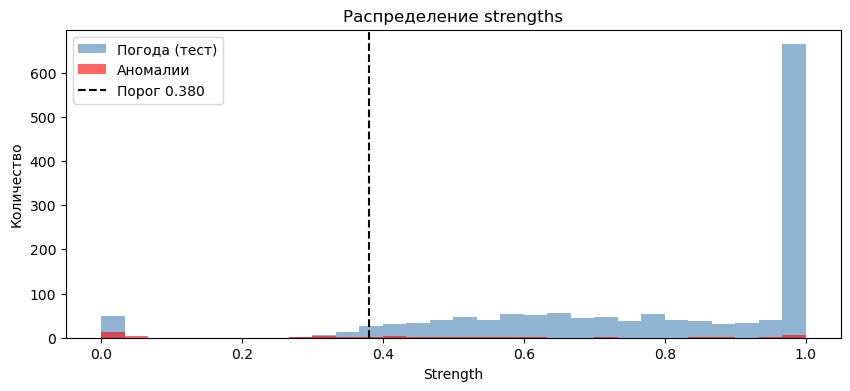

Погода — средний strength: 0.791
Аномалии — средний strength: 0.390


In [23]:
plt.figure(figsize=(10, 4))
plt.hist(test_strengths[test_labels_arr == 0], bins=30, alpha=0.6, color="steelblue", label="Погода (тест)")
plt.hist(test_strengths[test_labels_arr == 1], bins=30, alpha=0.6, color="red", label="Аномалии")
plt.axvline(x=best_threshold, color="black", linestyle="--", label=f"Порог {best_threshold:.3f}")
plt.xlabel("Strength")
plt.ylabel("Количество")
plt.legend()
plt.title("Распределение strengths")
plt.show()

print(f"Погода — средний strength: {test_strengths[test_labels_arr == 0].mean():.3f}")
print(f"Аномалии — средний strength: {test_strengths[test_labels_arr == 1].mean():.3f}")

In [24]:
print("\n=== необнаруженные аномалий (FN) ===")
anomalii = 0
for i, (true, pred, text) in enumerate(zip(test_labels, predictions, test_texts)):
    if true == 1 and pred == 0:
        print(f"  - {text}")
        anomalii+=1
print("anomalii упущено:",anomalii)
print("\n=== ложных срабатывания (FP) ===")
fp_count = 0
for i, (true, pred, text) in enumerate(zip(test_labels, predictions, test_texts)):
    if true == 0 and pred == 1:
        print(f"  - {text}")
        fp_count += 1
total_anomalies = sum(1 for l in test_labels if l == 1) 
fn = anomalii                                         
tp = total_anomalies - fn


print(f"Всего аномалий: {total_anomalies}")
print(f"Поймано (TP): {tp}")
print(f"Пропущено (FN): {fn}")
print(f"Recall: {tp / total_anomalies:.2%}")  


=== необнаруженные аномалий (FN) ===
  - Активиста арт-группы "Война" забрали в военкомат
  - Из-за катастрофы "Стрижи" не полетели на авиашоу в Тюмени
  - Российским чиновникам пригрозили пивной катастрофой
  - В Швейцарии по вине черепахи произошла автокатастрофа
  - Россия и США продолжат координировать шаги для избежания конфликтов над Сирией
  - Владелец клуба высказался о конфликте девушки-трансгендера с охраной
  - Авария на Московском НПЗ ликвидирована
  - Авария на шахте в Кемерово: под завалами оказались четыре горняка
  - Пресс-служба Чиркунова разъяснила суть конфликта с прессой
  - Из-за бунта в Кербенте на юге Киргизии могут ввести чрезвычайное положение
  - Мать с младенцем прожили пять дней в колумбийских джунглях после авиакатастрофы
  - В авиакатастрофе в Непале никто не выжил
  - Катастрофа на Азорских островах: 35 погибших
  - На роль R2-D2 в «Звездных войнах» нашли нового актера
  - "Бавария" пожаловалась на назначение российского судьи
  - Создатели «Игры престол

In [ ]:


joblib.dump(clusterer, "HDBSCAN_F1_optimized_v1.0.pkl")


['HDBSCAN_F1_optimized_v1.0.pkl']